# 01 — EDA + Feature Engineering

**Structure:** quality checks → feature engineering → EDA on everything together → save.
New features are built early so every correlation, heatmap, and scatter includes them.

**Input:** `data/raw/Sample Media Spend Data.csv`  
**Output:** `data/processed/clean.parquet`, `data/processed/eda_stats.json`

| Group | Features | Source |
|-------|---------|--------|
| Calendar | `week_of_year`, `month`, `quarter`, `year`, `is_q4`, `trend` | `date` column |
| Holidays | `has_federal_holiday`, `is_black_friday_week`, `is_back_to_school`, `is_easter_week` | US calendar |
| Macro | `consumer_sentiment`, `unemployment_rate` | FRED API (free, no key) |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.holiday import USFederalHolidayCalendar

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RAW  = Path('../data/raw')
PROC = Path('../data/processed')
PROC.mkdir(exist_ok=True)

DATE_COL     = 'date'
DIV_COL      = 'Division'
TARGET_COL   = 'Sales'
CHANNEL_COLS = [
    'Paid_Views',
    'Google_Impressions',
    'Email_Impressions',
    'Facebook_Impressions',
    'Affiliate_Impressions',
]

print('Setup complete.')

Setup complete.


## 1. Load & parse

In [2]:
raw = pd.read_csv(RAW / 'Sample Media Spend Data.csv')
raw['date'] = pd.to_datetime(raw['Calendar_Week'])
raw = raw.drop(columns=['Calendar_Week', 'Overall_Views'])
raw = raw.sort_values([DIV_COL, DATE_COL]).reset_index(drop=True)

print(raw.shape)
print('Date range:', raw['date'].min(), '→', raw['date'].max())
print('Divisions :', sorted(raw[DIV_COL].unique()))
raw.head()

(3051, 9)
Date range: 2018-01-06 00:00:00 → 2020-02-29 00:00:00
Divisions : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


,Division,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Sales,date
0,A,392,422,408,349895.0107,73580,12072,59417,2018-01-06
1,A,787,904,110,506270.2176,11804,9499,56806,2018-01-13
2,A,81,970,742,430042.1538,52232,17048,48715,2018-01-20
3,A,25,575,65,417745.6658,78640,10207,72047,2018-01-27
4,A,565,284,295,408505.8012,40561,5834,56235,2018-02-03


## 2. Quality checks — missing values, dtypes, panel balance

In [3]:
print('Dtypes:\n', raw.dtypes)
print('\nMissing values:')
print(raw.isnull().sum())
raw.describe()

Dtypes:
 Division                            str
Paid_Views                        int64
Organic_Views                     int64
Google_Impressions                int64
Email_Impressions               float64
Facebook_Impressions              int64
Affiliate_Impressions             int64
Sales                             int64
date                     datetime64[us]
dtype: object

Missing values:
Division                 0
Paid_Views               0
Organic_Views            0
Google_Impressions       0
Email_Impressions        0
Facebook_Impressions     0
Affiliate_Impressions    0
Sales                    0
date                     0
dtype: int64


,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Sales,date
count,3051.000000,3051.000000,3.051000e+03,3.051000e+03,3.051000e+03,3051.000000,3.051000e+03,3051
mean,15093.941658,13355.673222,8.861738e+05,7.605094e+05,2.691269e+05,22910.902655,1.859014e+05,2019-02-02 00:00:00
min,1.000000,1.000000,7.000000e+00,4.089445e+04,2.900000e+01,910.000000,1.543600e+04,2018-01-06 00:00:00
25%,537.000000,712.500000,1.698280e+05,3.784969e+05,5.707350e+04,9127.000000,7.339350e+04,2018-07-21 00:00:00
50%,2699.000000,4110.000000,4.905310e+05,5.909708e+05,1.275230e+05,16658.000000,1.135730e+05,2019-02-02 00:00:00
75%,17358.000000,16230.500000,1.022622e+06,9.622466e+05,2.835050e+05,27486.500000,2.029755e+05,2019-08-17 00:00:00
max,518190.000000,270453.000000,1.715044e+07,7.317730e+06,7.558435e+06,175791.000000,3.575430e+06,2020-02-29 00:00:00
std,30785.884979,24079.399689,1.355076e+06,6.260141e+05,4.665117e+05,21617.637497,2.322079e+05,NaN


In [4]:
weeks_per_div = raw.groupby(DIV_COL)['date'].nunique().sort_values()
print(weeks_per_div)
print('\nBalanced panel?', weeks_per_div.nunique() == 1)

Division
A    113
B    113
C    113
D    113
E    113
F    113
G    113
H    113
I    113
J    113
K    113
L    113
M    113
N    113
O    113
P    113
Q    113
R    113
S    113
T    113
U    113
V    113
W    113
X    113
Y    113
Z    113
Name: date, dtype: int64

Balanced panel? True


---
## Feature Engineering
Done here — before any EDA plots — so correlations and heatmaps cover
the new features alongside the original channels.

## 3. Calendar features

Zero external dependencies — derived entirely from `date`.

In [5]:
df = raw.copy()

# Raw calendar — kept in df for EDA plots and for computing Fourier terms
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['month']        = df['date'].dt.month
df['quarter']      = df['date'].dt.quarter
df['year']         = df['date'].dt.year
df['is_q4']        = (df['quarter'] == 4).astype(int)
df['trend']        = ((df['date'] - df['date'].min()).dt.days // 7).astype(int)

# Fourier seasonality terms — replace raw week_of_year in the model
# K=2 gives 4 terms: captures the fundamental annual cycle + semi-annual harmonic
# Much better than a raw integer because the model learns a smooth curve,
# not 52 independent week levels.
K = 2
for k in range(1, K + 1):
    df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['week_of_year'] / 52)
    df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['week_of_year'] / 52)

FOURIER_COLS  = [f'sin_{k}' for k in range(1, K+1)] + [f'cos_{k}' for k in range(1, K+1)]
# week_of_year / month / quarter stay in df for visualisation but are NOT model features
CALENDAR_COLS = ['is_q4', 'trend'] + FOURIER_COLS

print('Calendar + Fourier features added.')
print('CALENDAR_COLS (model features):', CALENDAR_COLS)
df[['date', 'week_of_year', 'is_q4', 'trend'] + FOURIER_COLS].drop_duplicates('date').head(8)

Calendar + Fourier features added.
CALENDAR_COLS (model features): ['is_q4', 'trend', 'sin_1', 'sin_2', 'cos_1', 'cos_2']


,date,week_of_year,is_q4,trend,sin_1,sin_2,cos_1,cos_2
0,2018-01-06,1,0,0,0.120537,0.239316,0.992709,0.970942
1,2018-01-13,2,0,1,0.239316,0.464723,0.970942,0.885456
2,2018-01-20,3,0,2,0.354605,0.663123,0.935016,0.748511
3,2018-01-27,4,0,3,0.464723,0.822984,0.885456,0.568065
4,2018-02-03,5,0,4,0.568065,0.935016,0.822984,0.354605
5,2018-02-10,6,0,5,0.663123,0.992709,0.748511,0.120537
6,2018-02-17,7,0,6,0.748511,0.992709,0.663123,-0.120537
7,2018-02-24,8,0,7,0.822984,0.935016,0.568065,-0.354605


### What do the Fourier terms actually capture?
Each sin/cos pair at frequency k captures one harmonic of the annual cycle.
- **K=1** (sin_1, cos_1): one peak + one trough per year — the dominant seasonal shape
- **K=2** (sin_2, cos_2): adds a second peak/trough — e.g. back-to-school + Q4 both appear

The plot below overlays the Fourier reconstruction against the actual mean Sales per week to show how well K=2 fits.

Fourier K=2 explains 60.2% of the variance in mean weekly Sales


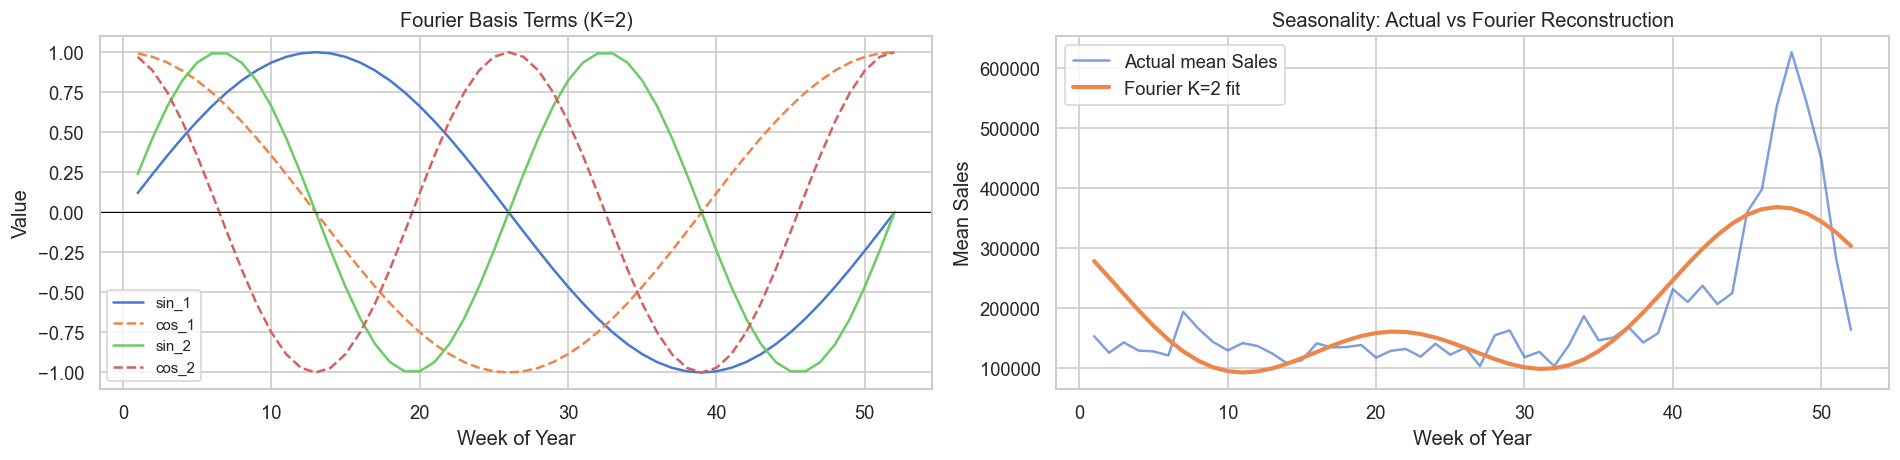

In [6]:
from numpy.linalg import lstsq

weeks = np.arange(1, 53)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: what each Fourier term looks like across the year
for k in range(1, K + 1):
    axes[0].plot(weeks, np.sin(2 * np.pi * k * weeks / 52), label=f'sin_{k}')
    axes[0].plot(weeks, np.cos(2 * np.pi * k * weeks / 52), label=f'cos_{k}', linestyle='--')
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].set_title(f'Fourier Basis Terms (K={K})')
axes[0].set_xlabel('Week of Year')
axes[0].set_ylabel('Value')
axes[0].legend(fontsize=9)

# Right: actual mean Sales per week vs Fourier reconstruction (OLS fit)
weekly_sales = df.groupby('week_of_year')[TARGET_COL].mean().sort_index()
X_f = np.column_stack([
    *[np.sin(2 * np.pi * k * weeks / 52) for k in range(1, K + 1)],
    *[np.cos(2 * np.pi * k * weeks / 52) for k in range(1, K + 1)],
    np.ones(52),
])
coefs, _, _, _ = lstsq(X_f, weekly_sales.values, rcond=None)
reconstructed  = X_f @ coefs

axes[1].plot(weeks, weekly_sales.values, alpha=0.7, label='Actual mean Sales')
axes[1].plot(weeks, reconstructed, linewidth=2.5, label=f'Fourier K={K} fit')
axes[1].set_title('Seasonality: Actual vs Fourier Reconstruction')
axes[1].set_xlabel('Week of Year')
axes[1].set_ylabel('Mean Sales')
axes[1].legend()

ss_res = ((weekly_sales.values - reconstructed) ** 2).sum()
ss_tot = ((weekly_sales.values - weekly_sales.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f'Fourier K={K} explains {r2*100:.1f}% of the variance in mean weekly Sales')

plt.tight_layout()
fig.savefig(PROC / 'fig_fourier_seasonality.png', bbox_inches='tight')

## 4. US Holiday flags

Holiday weeks cause sales spikes the model would otherwise misattribute
to whatever media channel happened to be running that week.

In [7]:
cal = USFederalHolidayCalendar()
holiday_dates = cal.holidays(start='2017-01-01', end='2020-12-31')
unique_dates  = df['date'].drop_duplicates().sort_values()

def week_has_holiday(week_start, holidays):
    week_end = week_start + pd.Timedelta(days=6)
    return int(((holidays >= week_start) & (holidays <= week_end)).any())

holiday_flag = {d: week_has_holiday(d, holiday_dates) for d in unique_dates}
df['has_federal_holiday'] = df['date'].map(holiday_flag)

# Black Friday = Friday after 4th Thursday of November
def black_friday_of(year):
    nov1 = pd.Timestamp(year, 11, 1)
    fourth_thu = nov1 + pd.Timedelta(days=(3 - nov1.weekday()) % 7) + pd.Timedelta(weeks=3)
    return fourth_thu + pd.Timedelta(days=1)

bf_dates = [black_friday_of(y) for y in df['year'].unique()]

def in_bf_week(week_start):
    week_end = week_start + pd.Timedelta(days=6)
    return int(any(week_start <= bf <= week_end for bf in bf_dates))

df['is_black_friday_week'] = df['date'].map({d: in_bf_week(d) for d in unique_dates})

# Back-to-school: ISO weeks 31–38 (late July → mid-Sep)
df['is_back_to_school'] = df['week_of_year'].between(31, 38).astype(int)

# Easter (manually verified for 2018–2020)
easter_dates = [pd.Timestamp('2018-04-01'), pd.Timestamp('2019-04-21'), pd.Timestamp('2020-04-12')]
df['is_easter_week'] = df['date'].map(
    {d: int(any(d <= e <= d + pd.Timedelta(days=6) for e in easter_dates)) for d in unique_dates}
)

HOLIDAY_COLS = ['has_federal_holiday','is_black_friday_week','is_back_to_school','is_easter_week']
print('Holiday weeks flagged (out of', df['date'].nunique(), 'unique weeks):')
for col in HOLIDAY_COLS:
    print(f'  {col:<25} {int(df.drop_duplicates("date")[col].sum()):>3} weeks')

Holiday weeks flagged (out of 113 unique weeks):
  has_federal_holiday        22 weeks
  is_black_friday_week        2 weeks
  is_back_to_school          16 weeks
  is_easter_week              2 weeks


## 5. Macro features — FRED (free, no API key)

Monthly series forward-filled to weekly. Falls back to column mean if no internet.

In [8]:
def fetch_fred(series_id, col_name):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    try:
        fred = pd.read_csv(url)
        fred.columns = fred.columns.str.strip()
        date_col = next(c for c in fred.columns if 'date' in c.lower())
        fred = fred.rename(columns={date_col: 'date', series_id: col_name})
        fred['date'] = pd.to_datetime(fred['date'])
        fred = fred[fred[col_name] != '.'].copy()
        fred[col_name] = fred[col_name].astype(float)
        print(f'  {series_id}: {len(fred)} monthly obs fetched')
        return fred[['date', col_name]]
    except Exception as e:
        print(f'  {series_id}: fetch failed ({e}) — using 0.0 fallback')
        return None

def merge_monthly(df_weekly, df_monthly, col):
    """Backward-fill monthly series onto weekly dates."""
    if df_monthly is None:
        df_weekly[col] = 0.0
        return df_weekly
    return pd.merge_asof(
        df_weekly.sort_values('date'),
        df_monthly.sort_values('date'),
        on='date', direction='backward'
    ).sort_values([DIV_COL, 'date']).reset_index(drop=True)

print('Fetching FRED series...')
umcsent  = fetch_fred('UMCSENT',  'consumer_sentiment')   # Univ. of Michigan sentiment
unrate   = fetch_fred('UNRATE',   'unemployment_rate')    # Unemployment rate (%)
cpi      = fetch_fred('CPIAUCSL', 'cpi')                  # Consumer Price Index (inflation)
psavert  = fetch_fred('PSAVERT',  'personal_savings_rate') # Personal savings rate (%)

df = merge_monthly(df, umcsent,  'consumer_sentiment')
df = merge_monthly(df, unrate,   'unemployment_rate')
df = merge_monthly(df, cpi,      'cpi')
df = merge_monthly(df, psavert,  'personal_savings_rate')

MACRO_COLS = ['consumer_sentiment', 'unemployment_rate', 'cpi', 'personal_savings_rate']

print('\nSample macro values (latest 6 unique weeks):')
print(df[['date'] + MACRO_COLS].drop_duplicates('date').tail(6).to_string(index=False))

Fetching FRED series...
  UMCSENT: 882 monthly obs fetched


  UNRATE: 941 monthly obs fetched
  CPIAUCSL: 952 monthly obs fetched


  PSAVERT: 808 monthly obs fetched

Sample macro values (latest 6 unique weeks):
      date  consumer_sentiment  unemployment_rate     cpi  personal_savings_rate
2020-01-25                99.8                3.6 259.127                    6.8
2020-02-01               101.0                3.5 259.250                    7.5
2020-02-08               101.0                3.5 259.250                    7.5
2020-02-15               101.0                3.5 259.250                    7.5
2020-02-22               101.0                3.5 259.250                    7.5
2020-02-29               101.0                3.5 259.250                    7.5


---
## EDA — all features
Feature engineering is done. Every plot below includes the new variables.

## 6. Sales time series — all divisions (small multiples)

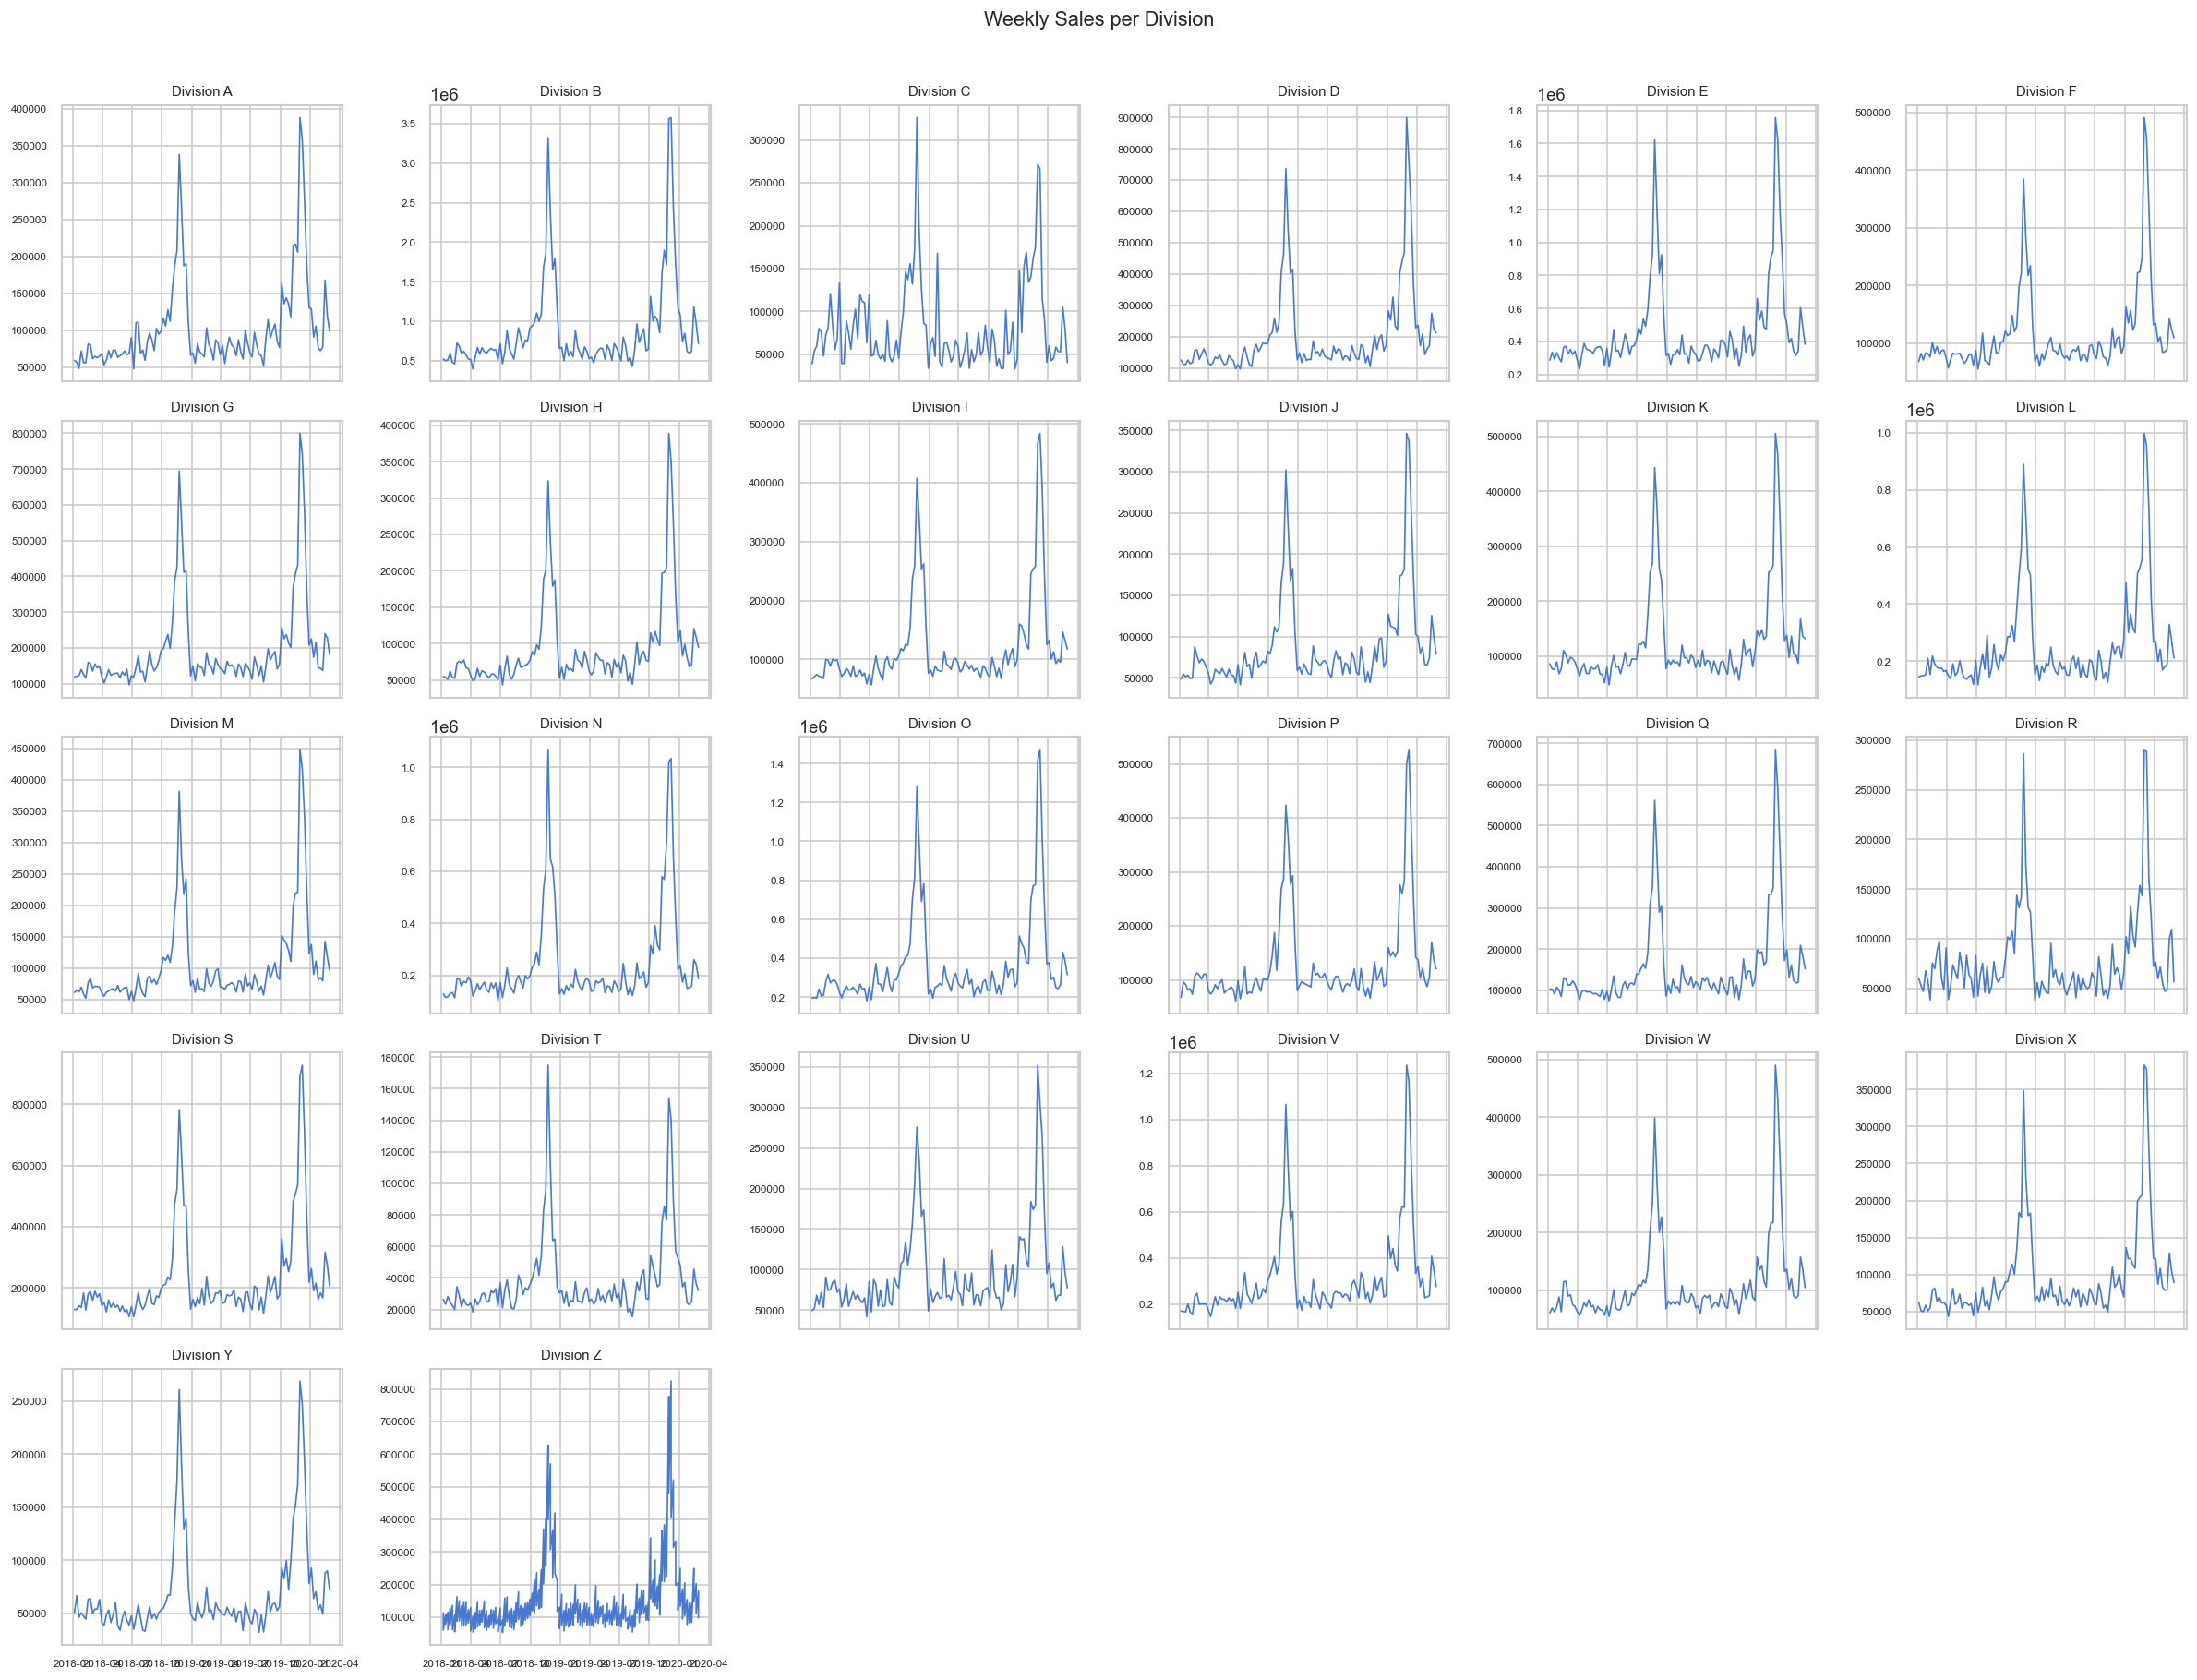

In [9]:
divisions = sorted(df[DIV_COL].unique())
ncols = 6
nrows = -(-len(divisions) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3), sharex=True)
for ax, div in zip(axes.flat, divisions):
    sub = df[df[DIV_COL] == div]
    ax.plot(sub['date'], sub[TARGET_COL], linewidth=1)
    ax.set_title(f'Division {div}', fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(divisions):]:
    ax.set_visible(False)

fig.suptitle('Weekly Sales per Division', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(PROC / 'fig_sales_small_multiples.png', bbox_inches='tight')

## 7. Seasonality — average Sales by month and week-of-year

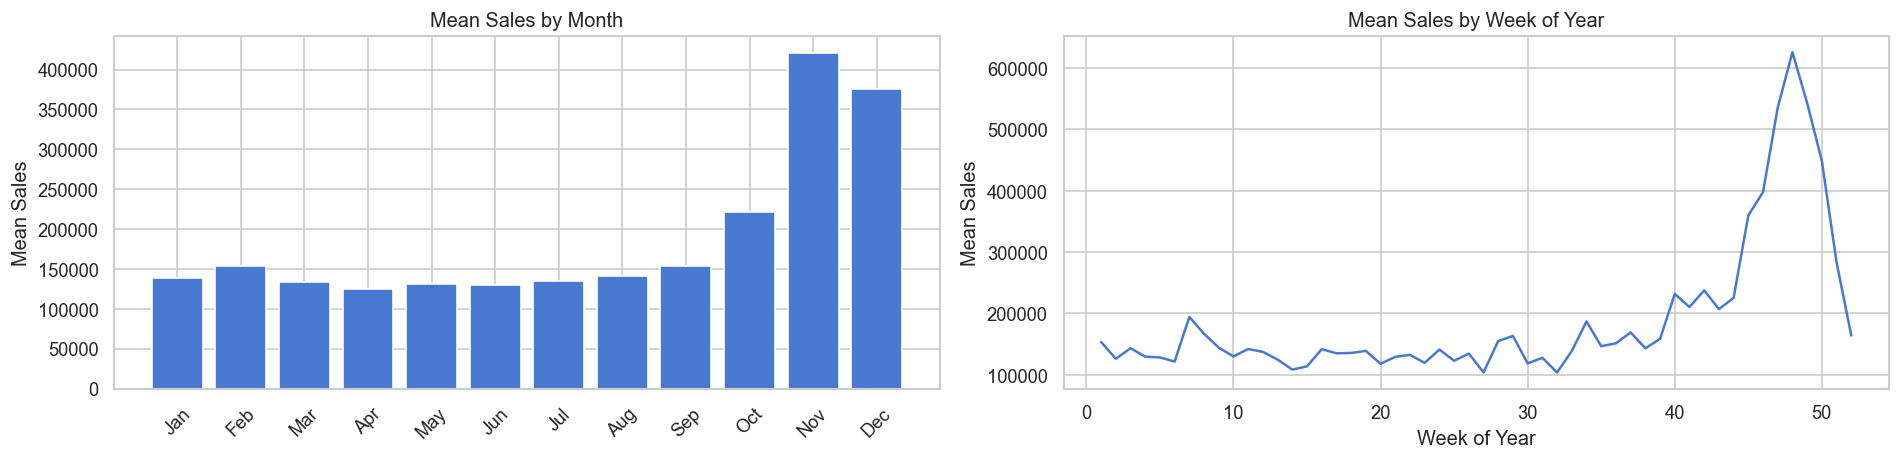

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# By month
monthly = df.groupby('month')[TARGET_COL].mean()
axes[0].bar(monthly.index, monthly.values)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].set_title('Mean Sales by Month')
axes[0].set_ylabel('Mean Sales')

# By week-of-year
weekly_avg = df.groupby('week_of_year')[TARGET_COL].mean()
axes[1].plot(weekly_avg.index, weekly_avg.values, linewidth=1.5)
axes[1].set_title('Mean Sales by Week of Year')
axes[1].set_xlabel('Week of Year')
axes[1].set_ylabel('Mean Sales')

plt.tight_layout()
fig.savefig(PROC / 'fig_seasonality.png', bbox_inches='tight')

## 8. Holiday impact on Sales

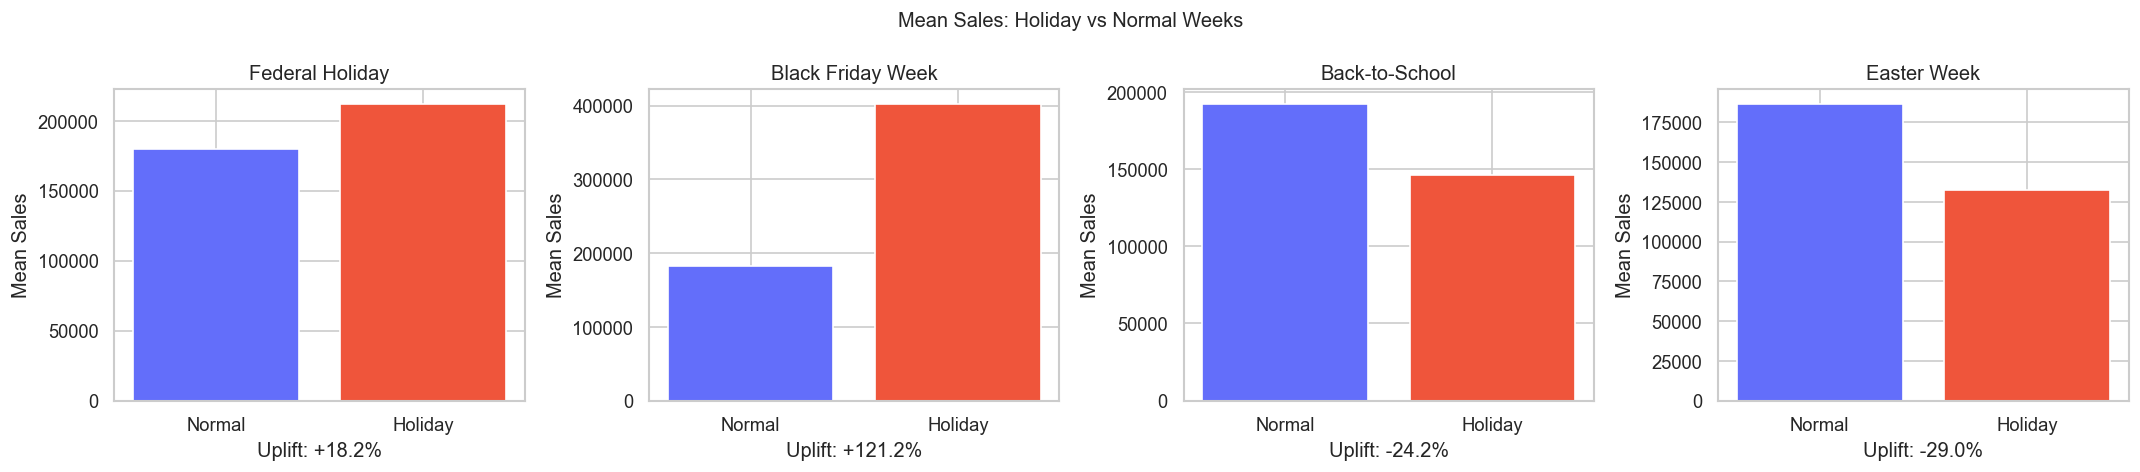

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ['Federal Holiday', 'Black Friday Week', 'Back-to-School', 'Easter Week']

for ax, col, title in zip(axes, HOLIDAY_COLS, titles):
    groups = df.groupby(col)[TARGET_COL].mean()
    bars = ax.bar(['Normal', 'Holiday'], [groups.get(0, 0), groups.get(1, 0)],
                  color=['#636EFA', '#EF553B'])
    ax.set_title(title)
    ax.set_ylabel('Mean Sales')
    uplift = (groups.get(1, 0) / groups.get(0, 1) - 1) * 100
    ax.set_xlabel(f'Uplift: {uplift:+.1f}%')

plt.suptitle('Mean Sales: Holiday vs Normal Weeks', fontsize=12)
plt.tight_layout()
fig.savefig(PROC / 'fig_holiday_impact.png', bbox_inches='tight')

## 9. Macro indicators vs total weekly Sales

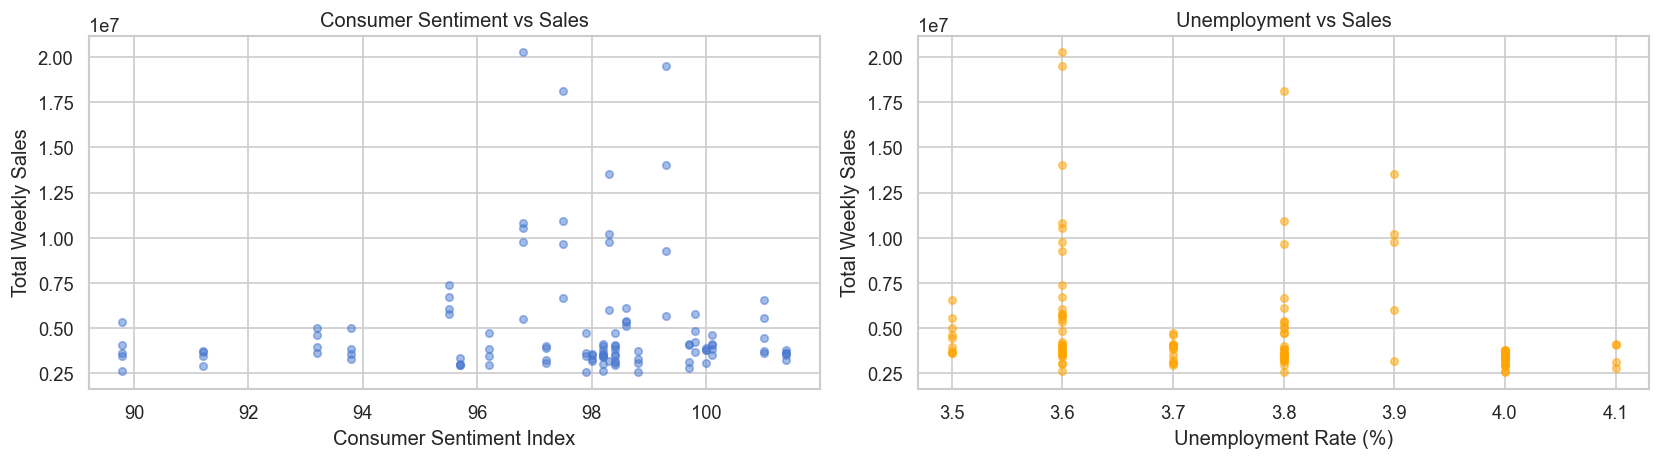

In [12]:
agg = df.groupby('date').agg(
    total_sales=(TARGET_COL, 'sum'),
    consumer_sentiment=('consumer_sentiment', 'first'),
    unemployment_rate=('unemployment_rate', 'first'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(agg['consumer_sentiment'], agg['total_sales'], alpha=0.5, s=20)
axes[0].set_xlabel('Consumer Sentiment Index')
axes[0].set_ylabel('Total Weekly Sales')
axes[0].set_title('Consumer Sentiment vs Sales')

axes[1].scatter(agg['unemployment_rate'], agg['total_sales'], alpha=0.5, s=20, color='orange')
axes[1].set_xlabel('Unemployment Rate (%)')
axes[1].set_ylabel('Total Weekly Sales')
axes[1].set_title('Unemployment vs Sales')

plt.tight_layout()
fig.savefig(PROC / 'fig_macro_vs_sales.png', bbox_inches='tight')

## 10. Channel spend distributions

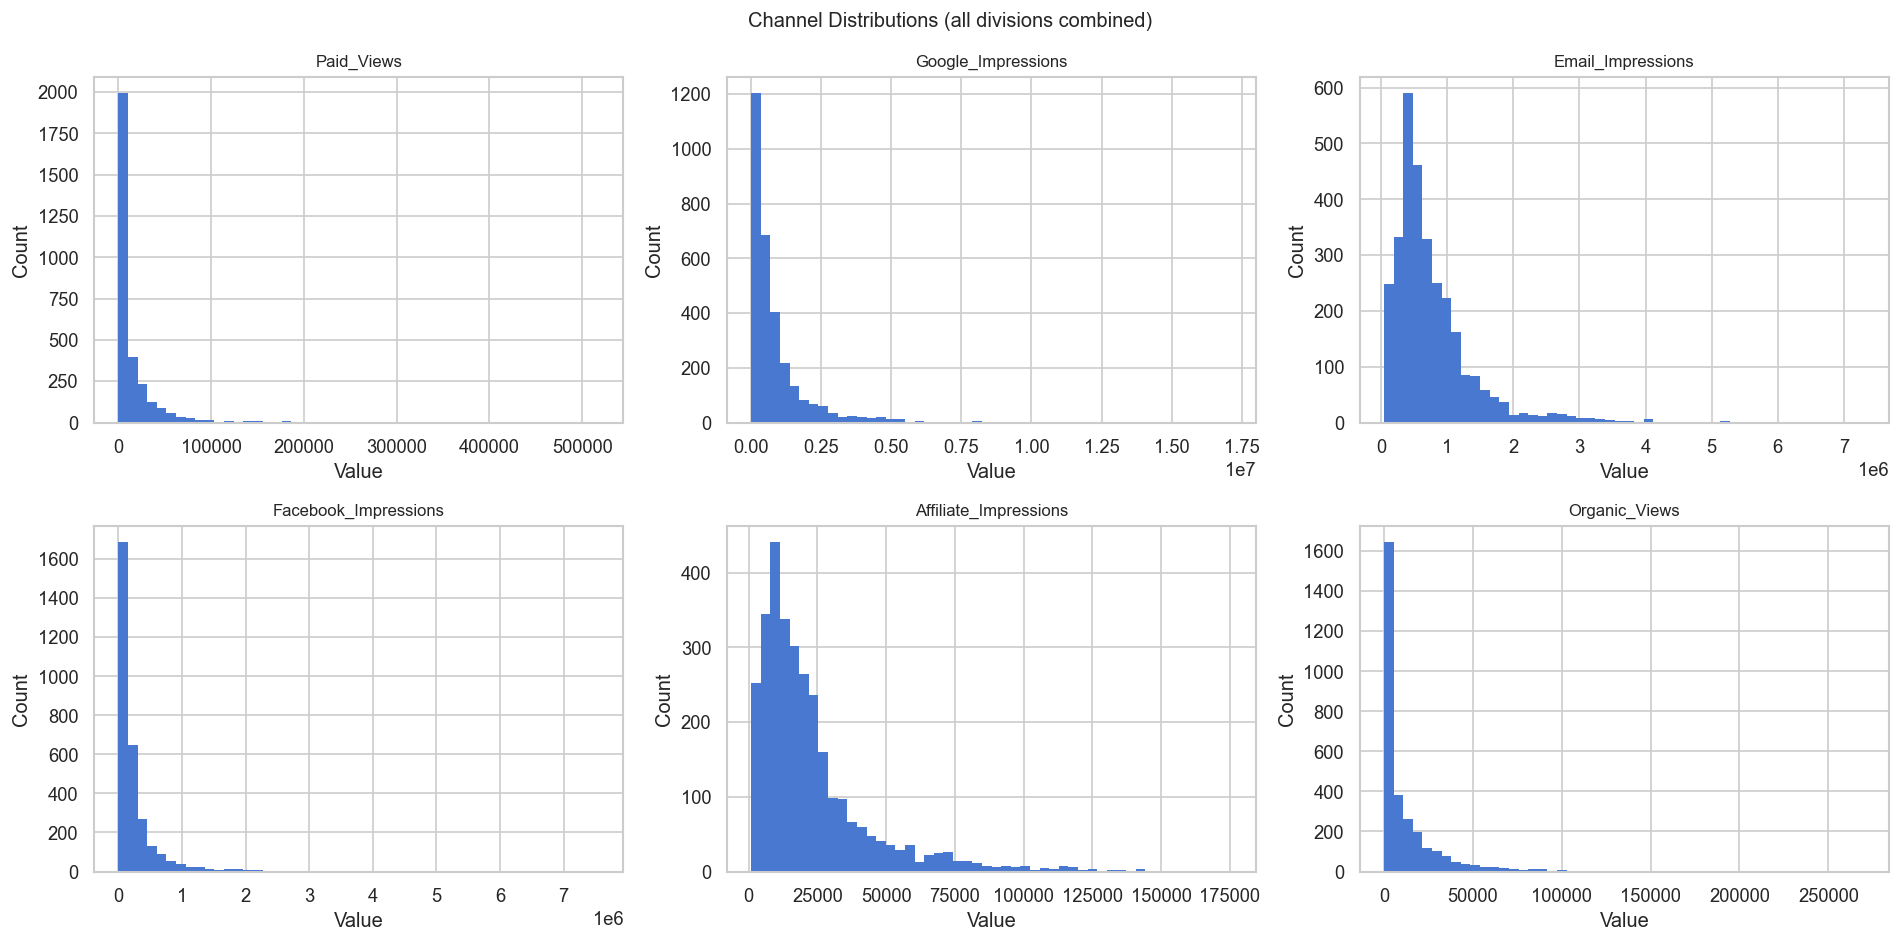

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_cols = CHANNEL_COLS + ['Organic_Views']
for ax, col in zip(axes.flat, plot_cols):
    ax.hist(df[col].dropna(), bins=50, edgecolor='none')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
for ax in axes.flat[len(plot_cols):]:
    ax.set_visible(False)

plt.suptitle('Channel Distributions (all divisions combined)', fontsize=12)
plt.tight_layout()
fig.savefig(PROC / 'fig_channel_distributions.png', bbox_inches='tight')

## 11. Zero-spend weeks per channel

In [14]:
zero_pct = (df[CHANNEL_COLS] == 0).mean() * 100
print('Percentage of zero-spend weeks per channel:')
print(zero_pct.to_string())

Percentage of zero-spend weeks per channel:
Paid_Views               0.0
Google_Impressions       0.0
Email_Impressions        0.0
Facebook_Impressions     0.0
Affiliate_Impressions    0.0


## 12. Correlation heatmap — channels + all new features vs Sales

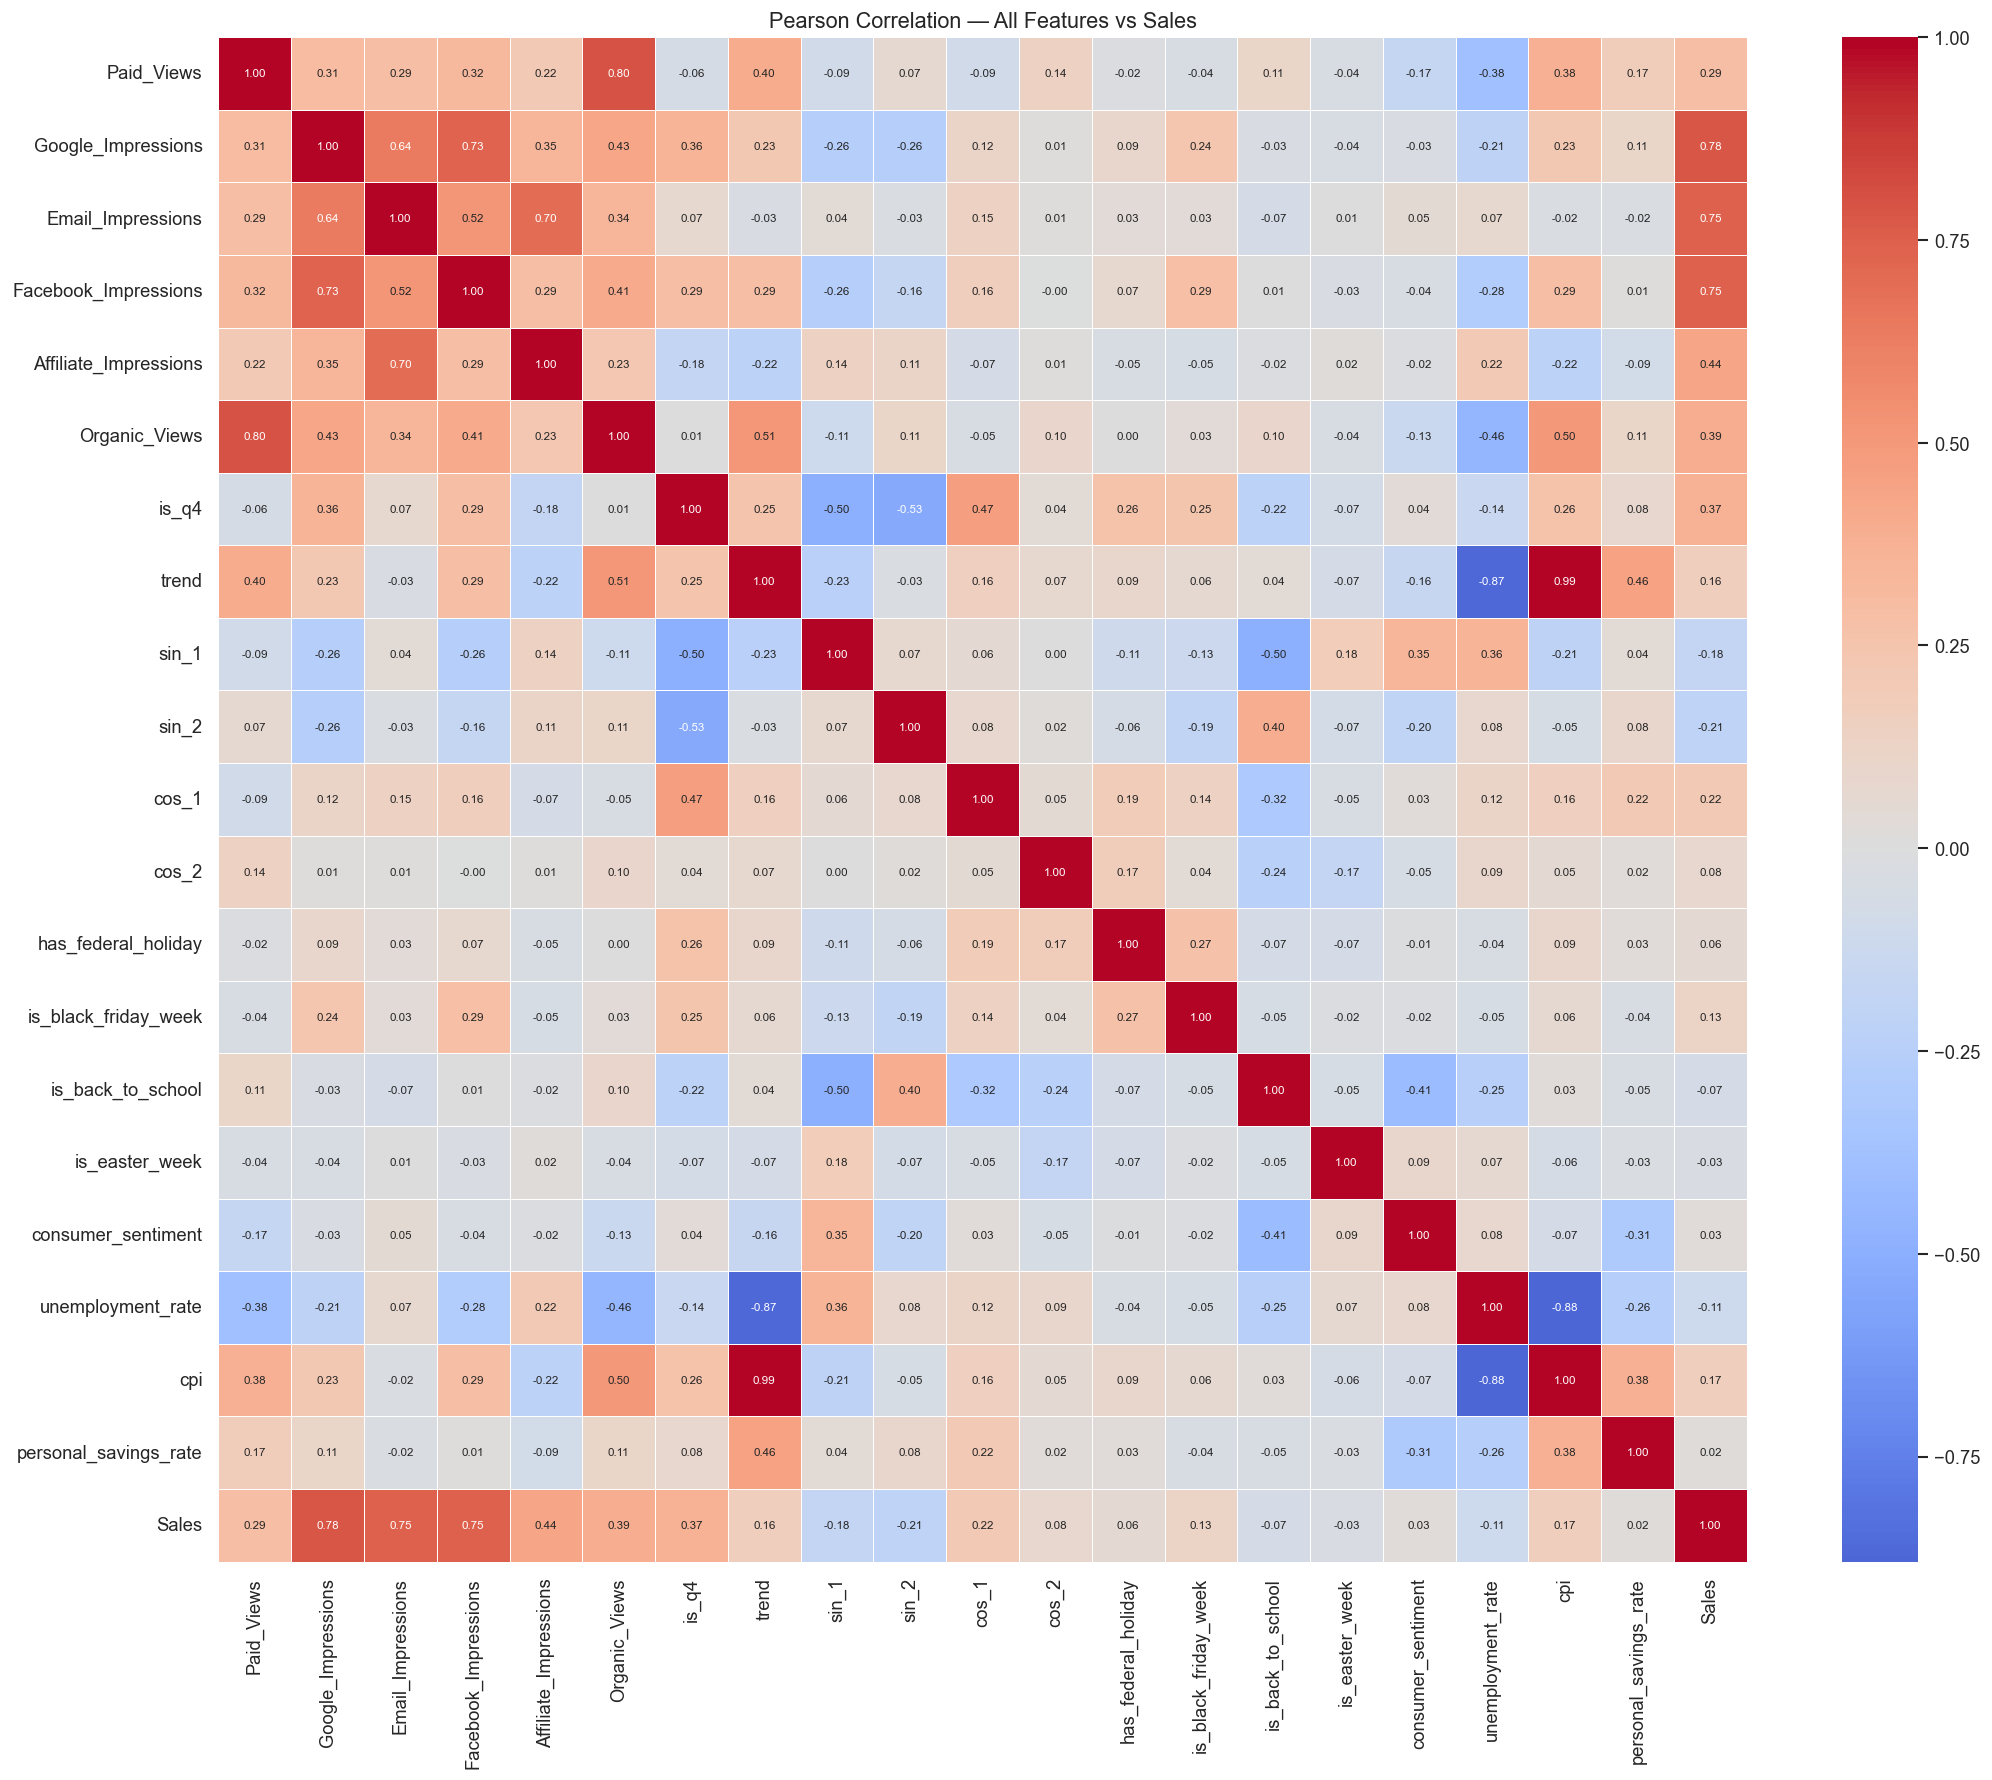

In [15]:
# CALENDAR_COLS and MACRO_COLS are defined in the feature engineering cells above
corr_cols = CHANNEL_COLS + ['Organic_Views'] + CALENDAR_COLS + HOLIDAY_COLS + MACRO_COLS + [TARGET_COL]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Pearson Correlation — All Features vs Sales', fontsize=13)
plt.tight_layout()
fig.savefig(PROC / 'fig_correlation_heatmap.png', bbox_inches='tight')

## 13. Feature importance — correlation with Sales (ranked)

sin_2                   -0.207558
sin_1                   -0.179431
unemployment_rate       -0.113648
is_back_to_school       -0.069948
is_easter_week          -0.030816
personal_savings_rate    0.019481
consumer_sentiment       0.028708
has_federal_holiday      0.055731
cos_2                    0.076074
is_black_friday_week     0.125299
trend                    0.164848
cpi                      0.169889
cos_1                    0.219563
Paid_Views               0.289688
is_q4                    0.371874
Organic_Views            0.390960
Affiliate_Impressions    0.440282
Email_Impressions        0.746729
Facebook_Impressions     0.749133
Google_Impressions       0.783338


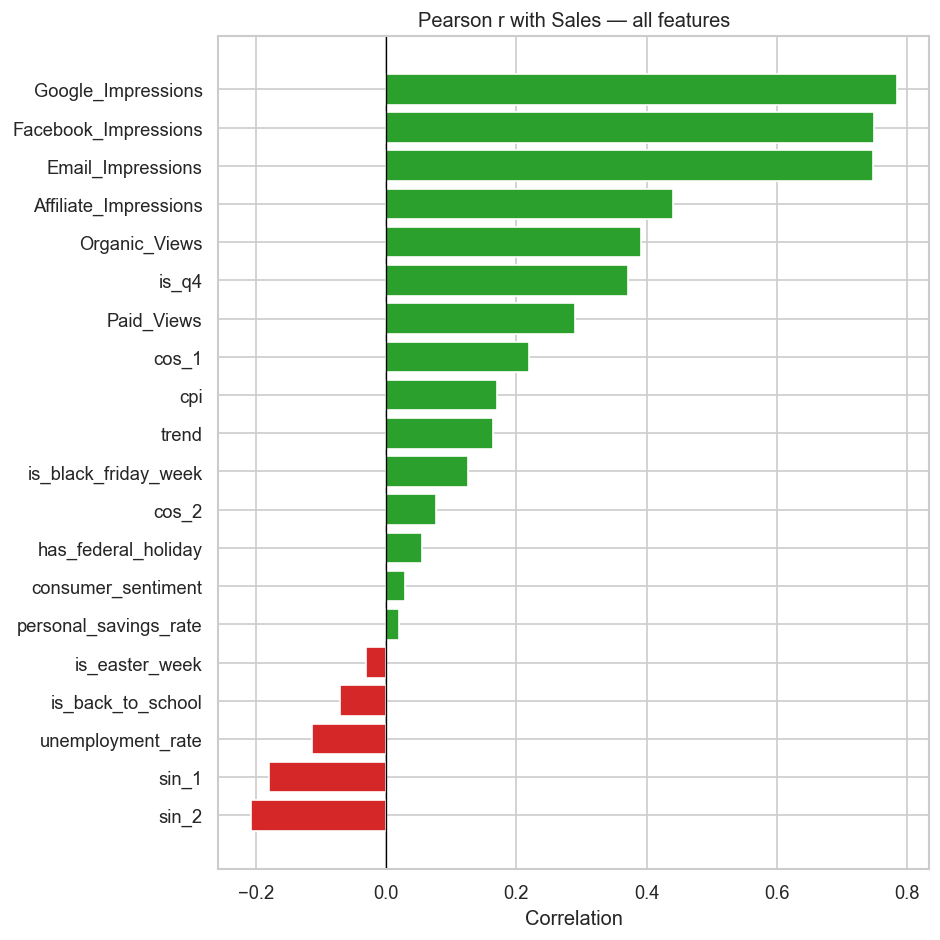

In [16]:
all_features = CHANNEL_COLS + ['Organic_Views'] + CALENDAR_COLS + HOLIDAY_COLS + MACRO_COLS
corr_with_sales = df[all_features + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in corr_with_sales.values]
ax.barh(corr_with_sales.index, corr_with_sales.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Pearson r with {TARGET_COL} — all features')
ax.set_xlabel('Correlation')
plt.tight_layout()
fig.savefig(PROC / 'fig_feature_correlations.png', bbox_inches='tight')

print(corr_with_sales.to_string())

## 14. Spend vs Sales scatter — channels

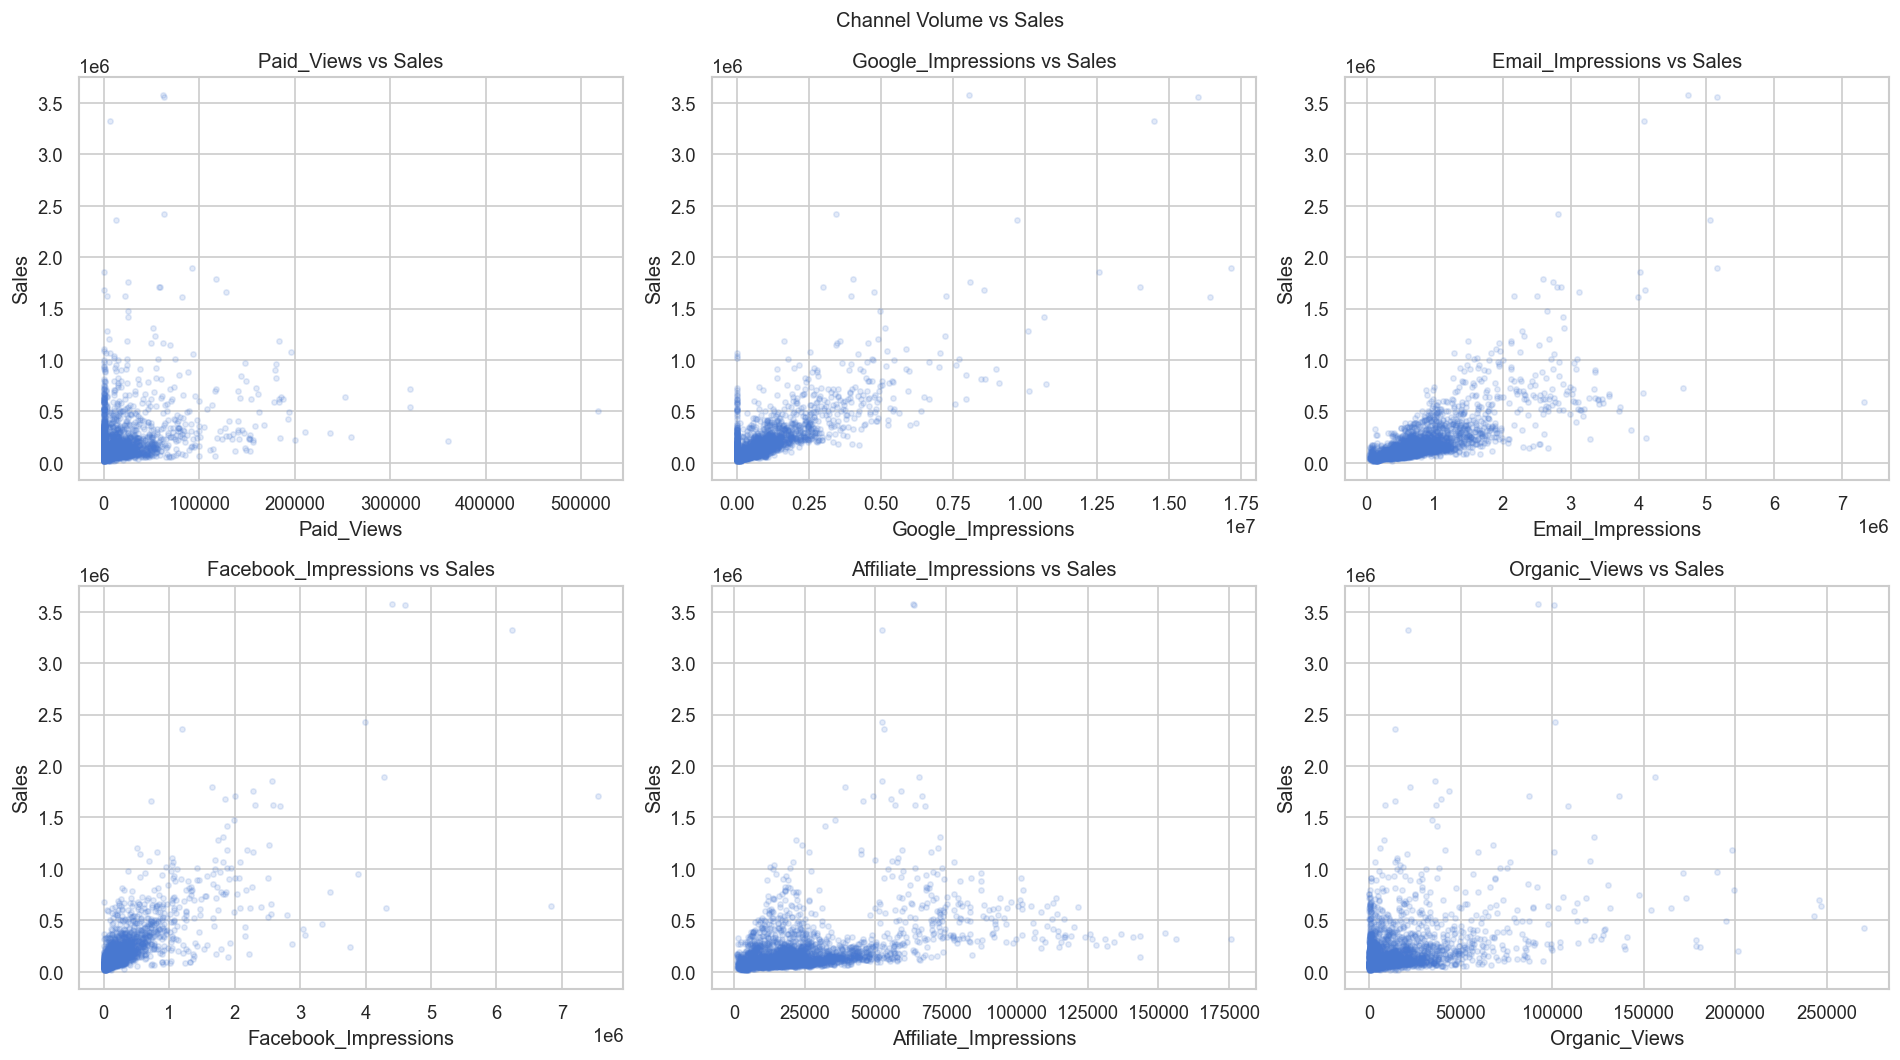

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, CHANNEL_COLS + ['Organic_Views']):
    ax.scatter(df[col], df[TARGET_COL], alpha=0.15, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
    ax.set_title(f'{col} vs {TARGET_COL}')
for ax in axes.flat[len(CHANNEL_COLS) + 1:]:
    ax.set_visible(False)
plt.suptitle('Channel Volume vs Sales', fontsize=12)
plt.tight_layout()
fig.savefig(PROC / 'fig_scatter_spend_vs_sales.png', bbox_inches='tight')

## 15. Rolling mean — stationarity check on Sales

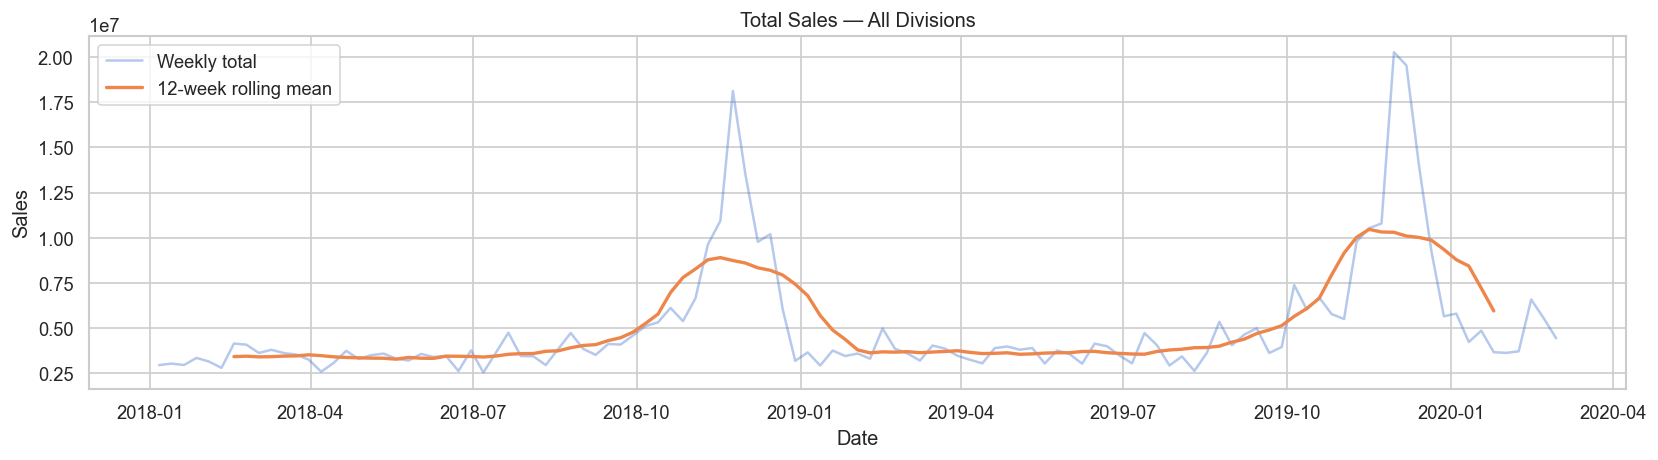

In [18]:
agg2 = df.groupby('date')[TARGET_COL].sum().reset_index()
agg2['rolling_12w'] = agg2[TARGET_COL].rolling(12, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(agg2['date'], agg2[TARGET_COL], alpha=0.4, label='Weekly total')
ax.plot(agg2['date'], agg2['rolling_12w'], linewidth=2, label='12-week rolling mean')
ax.set_title('Total Sales — All Divisions')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
fig.savefig(PROC / 'fig_sales_rolling.png', bbox_inches='tight')

## 16. Confirm final column list before saving

In [19]:
ALL_CONTROL_COLS = (
    ['Organic_Views']
    + CALENDAR_COLS
    + HOLIDAY_COLS
    + MACRO_COLS
)

missing = [c for c in ALL_CONTROL_COLS if c not in df.columns]
nulls   = df[ALL_CONTROL_COLS].isnull().sum()

print('Missing columns:', missing or 'none')
print('\nNull counts:')
print(nulls[nulls > 0] if nulls.any() else 'none')
print(f'\nTotal columns in final df: {len(df.columns)}')
print(list(df.columns))

Missing columns: none

Null counts:
none

Total columns in final df: 27
['Division', 'Paid_Views', 'Organic_Views', 'Google_Impressions', 'Email_Impressions', 'Facebook_Impressions', 'Affiliate_Impressions', 'Sales', 'date', 'week_of_year', 'month', 'quarter', 'year', 'is_q4', 'trend', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'has_federal_holiday', 'is_black_friday_week', 'is_back_to_school', 'is_easter_week', 'consumer_sentiment', 'unemployment_rate', 'cpi', 'personal_savings_rate']


## 17. Save summary stats + clean parquet

In [20]:
stats = {
    'n_rows': int(len(df)),
    'n_divisions': int(df[DIV_COL].nunique()),
    'date_min': str(df['date'].min().date()),
    'date_max': str(df['date'].max().date()),
    'channel_cols': CHANNEL_COLS,
    'control_cols': ALL_CONTROL_COLS,
    'target_col': TARGET_COL,
    'channel_means': df[CHANNEL_COLS].mean().round(1).to_dict(),
    'sales_mean': float(df[TARGET_COL].mean().round(1)),
    'sales_std': float(df[TARGET_COL].std().round(1)),
    'macro_available': bool(df['consumer_sentiment'].notna().all()),
}
with open(PROC / 'eda_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

df.to_parquet(PROC / 'clean.parquet', index=False)
print(f'Saved {len(df):,} rows → data/processed/clean.parquet')
print(f'{len(df.columns)} columns:', list(df.columns))

Saved 3,051 rows → data/processed/clean.parquet
27 columns: ['Division', 'Paid_Views', 'Organic_Views', 'Google_Impressions', 'Email_Impressions', 'Facebook_Impressions', 'Affiliate_Impressions', 'Sales', 'date', 'week_of_year', 'month', 'quarter', 'year', 'is_q4', 'trend', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'has_federal_holiday', 'is_black_friday_week', 'is_back_to_school', 'is_easter_week', 'consumer_sentiment', 'unemployment_rate', 'cpi', 'personal_savings_rate']
